# Reto 2: Métodos de Exploración y Explotación — K-Armed Bandit

**Curso:** Aprendizaje por refuerzo — Sesión 2
**Profesor:** Juan Camilo Tejada Orjuela, Ph.D.(C) — Universidad EIA

**Nombres:** _[Escribe aquí los nombres del equipo]_
**Fecha:** _[Escribe la fecha]_

## Objetivo del notebook
Retomar el simulador K-Armed Bandit del Reto 1 (3 máquinas con distribución normal) e implementar y comparar distintos **métodos de exploración y explotación** que un agente puede usar para decidir qué máquina jugar en cada paso, sin conocer de antemano los valores reales $Q^*(a)$:

- **Greedy (voraz puro):** siempre explota la mejor estimación actual.
- **Epsilon-Greedy:** explota casi siempre, pero explora al azar con probabilidad $\varepsilon$.
- **UCB (Upper Confidence Bound):** explora de forma dirigida, priorizando brazos con más incertidumbre.
- **Softmax (Boltzmann):** elige probabilísticamente según qué tan buena luce cada estimación.

Para cada método mediremos la **recompensa promedio por jugada** y el **% de veces que se elige la máquina óptima**, promediando muchas corridas independientes para obtener curvas estables.

## Definición del problema

| Máquina $(a)$ | Distribución | $\mu$ (real) | $\sigma$ (real) |
|:---:|:---:|:---:|:---:|
| $A_1$ | Normal | 1.0 | 0.5 |
| $A_2$ | Normal | **2.0** | 0.5 |
| $A_3$ | Normal | 1.5 | **1.5** |

El valor real de cada acción es $Q^*(a) = \mathbb{E}[R_t \mid A_t = a] = \mu$. La máquina óptima es $A_2$ ($Q^*(A_2) = 2.0$). El agente **no conoce** estos valores: debe estimarlos como $Q_t(a)$ mientras decide, en cada jugada, si **explotar** lo que ya sabe o **explorar** para aprender más.

## Dilema exploración vs. explotación

- **Explotar** = elegir la máquina con mayor $Q_t(a)$ conocido hasta el momento → maximiza la recompensa *a corto plazo*, pero puede quedarse atascado en una estimación equivocada (sobre todo con la varianza alta de $A_3$).
- **Explorar** = probar máquinas distintas a la "mejor conocida" → mejora las estimaciones $Q_t(a)$ y puede revelar una mejor opción, a costa de recompensa inmediata.

Cada método de este notebook resuelve este balance de una forma distinta.

## 1. Configuración e importaciones (mismos valores del Reto 1)

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Semilla para que los resultados sean reproducibles
rng = np.random.default_rng(seed=42)

# Parámetros reales de las máquinas: (mu, sigma) — igual que en el Reto 1
MAQUINAS = {
    "A1": {"mu": 1.0, "sigma": 0.5},
    "A2": {"mu": 2.0, "sigma": 0.5},
    "A3": {"mu": 1.5, "sigma": 1.5},
}

ARMS = list(MAQUINAS.keys())          # ["A1", "A2", "A3"]
K = len(ARMS)                         # número de brazos (máquinas)
Q_STAR = np.array([MAQUINAS[a]["mu"] for a in ARMS])   # valores reales Q*(a)
OPTIMO = int(np.argmax(Q_STAR))       # índice del brazo óptimo real

N_JUGADAS = 1_000    # número de jugadas por corrida (igual que Reto 1)
N_CORRIDAS = 200     # número de corridas independientes para promediar

print(f"Brazos: {ARMS}")
print(f"Q*(a) real: {dict(zip(ARMS, Q_STAR))}")
print(f"Brazo óptimo real: {ARMS[OPTIMO]} (Q* = {Q_STAR[OPTIMO]})")

Brazos: ['A1', 'A2', 'A3']
Q*(a) real: {'A1': np.float64(1.0), 'A2': np.float64(2.0), 'A3': np.float64(1.5)}
Brazo óptimo real: A2 (Q* = 2.0)


## 2. Función `reward(arm_idx)`

Igual que en el Reto 1: al "jalar" un brazo, la recompensa es una muestra de $N(\mu, \sigma)$ de esa máquina. Esta es la "verdad oculta" que el agente no conoce y que solo puede estimar jugando.

In [2]:
def reward(arm_idx: int) -> float:
    """Entrega una recompensa aleatoria de la distribución normal
    de la máquina en la posición `arm_idx` (0, 1 o 2)."""
    p = MAQUINAS[ARMS[arm_idx]]
    return rng.normal(loc=p["mu"], scale=p["sigma"])

## 3. Motor genérico del agente

Todos los métodos comparten el mismo ciclo: en cada jugada $t$, la **política** decide qué brazo jugar a partir de las estimaciones actuales $Q_t(a)$ y el conteo de veces que se ha jugado cada brazo $N(a)$; luego se observa la recompensa y se actualiza $Q_t(a)$ con la regla incremental vista en el Reto 1:

$$Q_{t+1}(a) = Q_t(a) + \frac{1}{N(a)}\left(R_{t+1} - Q_t(a)\right)$$

Separar la "política" (cómo elegir) del "motor" (cómo actualizar) permite reutilizar el mismo código para Greedy, Epsilon-Greedy, UCB y Softmax.

In [3]:
def ejecutar_agente(politica, n_jugadas=N_JUGADAS):
    """Ejecuta una corrida completa del bandido con la política dada.

    Parámetros
    ----------
    politica : callable(Q, N, t) -> int
        Función que recibe las estimaciones Q, los conteos N y el
        paso actual t, y retorna el índice del brazo elegido.

    Retorna
    -------
    recompensas : np.ndarray, shape (n_jugadas,)
        Recompensa obtenida en cada jugada.
    es_optima : np.ndarray, shape (n_jugadas,)
        True si en esa jugada se eligió el brazo óptimo real.
    """
    Q = np.zeros(K)
    N = np.zeros(K, dtype=int)
    recompensas = np.zeros(n_jugadas)
    es_optima = np.zeros(n_jugadas, dtype=bool)

    for t in range(n_jugadas):
        a = politica(Q, N, t)
        R = reward(a)
        N[a] += 1
        Q[a] += (1.0 / N[a]) * (R - Q[a])
        recompensas[t] = R
        es_optima[t] = (a == OPTIMO)

    return recompensas, es_optima


def experimento(politica_fn, n_corridas=N_CORRIDAS, n_jugadas=N_JUGADAS):
    """Repite `ejecutar_agente` n_corridas veces y promedia los resultados,
    para obtener curvas estables (menos ruido que una sola corrida)."""
    todas_recompensas = np.zeros((n_corridas, n_jugadas))
    todas_optimas = np.zeros((n_corridas, n_jugadas))

    for i in range(n_corridas):
        r, o = ejecutar_agente(politica_fn, n_jugadas)
        todas_recompensas[i] = r
        todas_optimas[i] = o

    recompensa_promedio = todas_recompensas.mean(axis=0)
    pct_optima = todas_optimas.mean(axis=0) * 100
    return recompensa_promedio, pct_optima

In [4]:
def ejecutar_agente_con_Q(politica, n_jugadas=N_JUGADAS):
    """Igual que `ejecutar_agente`, pero retorna únicamente el Q(a) final,
    útil para comparar contra Q*(a) justo después de correr cada método."""
    Q = np.zeros(K)
    N = np.zeros(K, dtype=int)
    for t in range(n_jugadas):
        a = politica(Q, N, t)
        R = reward(a)
        N[a] += 1
        Q[a] += (1.0 / N[a]) * (R - Q[a])
    return Q.copy()


def Q_final_promedio(politica, n_corridas=N_CORRIDAS, n_jugadas=N_JUGADAS):
    """Repite la corrida n_corridas veces y promedia las estimaciones finales Q(a),
    para comparar de forma estable contra el valor real Q*(a)."""
    todas_Q = np.zeros((n_corridas, K))
    for i in range(n_corridas):
        todas_Q[i] = ejecutar_agente_con_Q(politica, n_jugadas)
    return todas_Q.mean(axis=0), todas_Q.std(axis=0)


def mostrar_resultados_maquinas(nombre_metodo, politicas_por_config):
    """Imprime, para cada configuración probada de un método, la estimación final
    Q(a) de cada máquina frente a su valor real Q*(a) y el error absoluto promedio.

    `politicas_por_config` es un dict {etiqueta: politica_callable}.
    """
    encabezado = f"{'Configuración':<22}" + "".join(
        f"{a + ' (real=' + str(Q_STAR[i]) + ')':>24}" for i, a in enumerate(ARMS)
    )
    print(f"--- {nombre_metodo}: resultados por máquina tras {N_JUGADAS} jugadas ({N_CORRIDAS} corridas) ---")
    print(encabezado)
    print("-" * len(encabezado))
    for etiqueta, politica in politicas_por_config.items():
        Q_prom, _ = Q_final_promedio(politica)
        fila = f"{etiqueta:<22}"
        for i in range(K):
            error = Q_prom[i] - Q_STAR[i]
            fila += f"{Q_prom[i]:>16.3f} ({error:+.3f})"
        error_abs_prom = np.abs(Q_prom - Q_STAR).mean()
        fila += f"   | error abs. prom.: {error_abs_prom:.4f}"
        print(fila)
    print()

## 4. Método Greedy (voraz puro)

En cada paso elige el brazo con mayor $Q_t(a)$ actual, sin excepción. Como todas las estimaciones parten en 0, el primer brazo (`A1`) gana el primer empate y suele quedarse "atascado" ahí si su primera recompensa es alta: es el ejemplo clásico de **pura explotación, sin exploración**.

In [5]:
def politica_greedy(Q, N, t):
    return int(np.argmax(Q))


recompensa_greedy, optima_greedy = experimento(politica_greedy)
print(f"Greedy — recompensa promedio final (últimas 100 jugadas): {recompensa_greedy[-100:].mean():.4f}")
print(f"Greedy — % elección óptima final (últimas 100 jugadas): {optima_greedy[-100:].mean():.2f}%")

Greedy — recompensa promedio final (últimas 100 jugadas): 1.0247
Greedy — % elección óptima final (últimas 100 jugadas): 2.50%


In [6]:
mostrar_resultados_maquinas("Greedy", {"Greedy": politica_greedy})

--- Greedy: resultados por máquina tras 1000 jugadas (200 corridas) ---
Configuración                    A1 (real=1.0)           A2 (real=2.0)           A3 (real=1.5)
----------------------------------------------------------------------------------------------


Greedy                           0.990 (-0.010)           0.020 (-1.980)           0.000 (-1.500)   | error abs. prom.: 1.1634



## 5. Método Epsilon-Greedy

Con probabilidad $\varepsilon$ se **explora** (brazo aleatorio); con probabilidad $1-\varepsilon$ se **explota** (mejor $Q_t(a)$ conocido). Comparamos varios valores de $\varepsilon$, incluyendo $\varepsilon=0$ (que es idéntico a Greedy) para verificar la implementación.

In [7]:
def politica_epsilon_greedy(epsilon):
    def politica(Q, N, t):
        if rng.random() < epsilon:
            return int(rng.integers(K))   # explorar: brazo aleatorio
        return int(np.argmax(Q))          # explotar: mejor conocido
    return politica


EPSILONS = [0.0, 0.01, 0.1, 0.3]
resultados_eps = {}

for eps in EPSILONS:
    r, o = experimento(politica_epsilon_greedy(eps))
    resultados_eps[eps] = {"recompensa": r, "optima": o}
    print(f"epsilon={eps:<5} | recompensa final: {r[-100:].mean():.4f} | % óptima final: {o[-100:].mean():.2f}%")

epsilon=0.0   | recompensa final: 1.0160 | % óptima final: 1.50%


epsilon=0.01  | recompensa final: 1.9661 | % óptima final: 94.75%


epsilon=0.1   | recompensa final: 1.9499 | % óptima final: 93.14%


epsilon=0.3   | recompensa final: 1.8514 | % óptima final: 79.52%


In [8]:
mostrar_resultados_maquinas(
    "Epsilon-Greedy",
    {f"epsilon={eps}": politica_epsilon_greedy(eps) for eps in EPSILONS},
)

--- Epsilon-Greedy: resultados por máquina tras 1000 jugadas (200 corridas) ---
Configuración                    A1 (real=1.0)           A2 (real=2.0)           A3 (real=1.5)
----------------------------------------------------------------------------------------------


epsilon=0.0                      0.958 (-0.042)           0.070 (-1.930)           0.000 (-1.500)   | error abs. prom.: 1.1572


epsilon=0.01                     0.986 (-0.014)           1.935 (-0.065)           1.244 (-0.256)   | error abs. prom.: 0.1115


epsilon=0.1                      1.002 (+0.002)           2.001 (+0.001)           1.470 (-0.030)   | error abs. prom.: 0.0111


epsilon=0.3                      1.003 (+0.003)           2.000 (-0.000)           1.490 (-0.010)   | error abs. prom.: 0.0043



## 6. Método UCB (Upper Confidence Bound)

En vez de explorar al azar, UCB explora de forma **dirigida**: prioriza brazos que se han probado poco (alta incertidumbre). La regla de selección es

$$A_t = \arg\max_a \left[ Q_t(a) + c \sqrt{\frac{\ln t}{N(a)}} \right]$$

donde $c$ controla cuánto se premia la incertidumbre. Cada brazo se prueba al menos una vez antes de aplicar la fórmula (para evitar dividir entre $N(a)=0$).

Probamos dos valores de $c$: uno fijo, $c=0.70$, y uno aleatorio $c \sim U(0,1)$ generado con semilla `420` (reproducible), para comparar un valor fijo razonable contra uno elegido al azar.

In [9]:
def politica_ucb(c):
    def politica(Q, N, t):
        no_probados = np.where(N == 0)[0]
        if len(no_probados) > 0:
            return int(no_probados[0])    # probar primero cada brazo una vez
        ucb = Q + c * np.sqrt(np.log(t + 1) / N)
        return int(np.argmax(ucb))
    return politica


# c inicial fijo en 0.70; el segundo valor es aleatorio Uniform(0,1) con semilla 420
c_aleatorio = float(np.random.default_rng(420).uniform(0, 1))
VALORES_C = [0.70, c_aleatorio]
resultados_ucb = {}

for c in VALORES_C:
    r, o = experimento(politica_ucb(c))
    resultados_ucb[c] = {"recompensa": r, "optima": o}
    print(f"c={c:<20.4f} | recompensa final: {r[-100:].mean():.4f} | % óptima final: {o[-100:].mean():.2f}%")

c=0.7000               | recompensa final: 1.9901 | % óptima final: 99.29%


c=0.7774               | recompensa final: 1.9983 | % óptima final: 99.83%


In [10]:
mostrar_resultados_maquinas(
    "UCB",
    {f"c={c:.4f}": politica_ucb(c) for c in VALORES_C},
)

--- UCB: resultados por máquina tras 1000 jugadas (200 corridas) ---
Configuración                    A1 (real=1.0)           A2 (real=2.0)           A3 (real=1.5)
----------------------------------------------------------------------------------------------


c=0.7000                         0.874 (-0.126)           2.001 (+0.001)           0.817 (-0.683)   | error abs. prom.: 0.2700


c=0.7774                         0.872 (-0.128)           2.000 (-0.000)           0.768 (-0.732)   | error abs. prom.: 0.2871



## 7. Método Softmax (Boltzmann)

Convierte las estimaciones $Q_t(a)$ en una distribución de probabilidad y elige el brazo **muestreando** de ella, en vez de tomar siempre el máximo:

$$P(A_t = a) = \frac{e^{Q_t(a)/\tau}}{\sum_{b} e^{Q_t(b)/\tau}}$$

La temperatura $\tau$ controla el balance: con $\tau \to 0$ el comportamiento se acerca a Greedy (casi determinista); con $\tau$ grande, la elección se acerca a uniforme aleatoria (más exploración).

Igual que con UCB, probamos dos valores de $\tau$: uno fijo, $\tau=0.70$, y uno aleatorio $\tau \sim U(0,1)$ generado con semilla `420` (reproducible).

In [11]:
def politica_softmax(tau):
    def politica(Q, N, t):
        Q_estable = Q - Q.max()              # evita overflow en la exponencial
        exp_q = np.exp(Q_estable / tau)
        probs = exp_q / exp_q.sum()
        return int(rng.choice(K, p=probs))
    return politica


# tau inicial fijo en 0.70; el segundo valor es aleatorio Uniform(0,1) con semilla 420
tau_aleatorio = float(np.random.default_rng(420).uniform(0, 1))
TAUS = [0.70, tau_aleatorio]
resultados_softmax = {}

for tau in TAUS:
    r, o = experimento(politica_softmax(tau))
    resultados_softmax[tau] = {"recompensa": r, "optima": o}
    print(f"tau={tau:<18.4f} | recompensa final: {r[-100:].mean():.4f} | % óptima final: {o[-100:].mean():.2f}%")

tau=0.7000             | recompensa final: 1.7140 | % óptima final: 57.97%


tau=0.7774             | recompensa final: 1.6945 | % óptima final: 54.66%


In [12]:
mostrar_resultados_maquinas(
    "Softmax",
    {f"tau={tau:.4f}": politica_softmax(tau) for tau in TAUS},
)

--- Softmax: resultados por máquina tras 1000 jugadas (200 corridas) ---
Configuración                    A1 (real=1.0)           A2 (real=2.0)           A3 (real=1.5)
----------------------------------------------------------------------------------------------


tau=0.7000                       1.000 (+0.000)           2.000 (+0.000)           1.469 (-0.031)   | error abs. prom.: 0.0108


tau=0.7774                       0.998 (-0.002)           1.999 (-0.001)           1.491 (-0.009)   | error abs. prom.: 0.0039



## 8. Comparación gráfica de todos los métodos

Para la comparación final usamos, de cada familia, la configuración que mejor equilibrio mostró en las secciones anteriores: **Greedy**, **Epsilon-Greedy ($\varepsilon=0.1$)**, **UCB ($c=0.70$)** y **Softmax ($\tau=0.70$)**. *(Si tus resultados varían, ajusta estos valores por los que mejor desempeño hayan dado en tu ejecución.)*

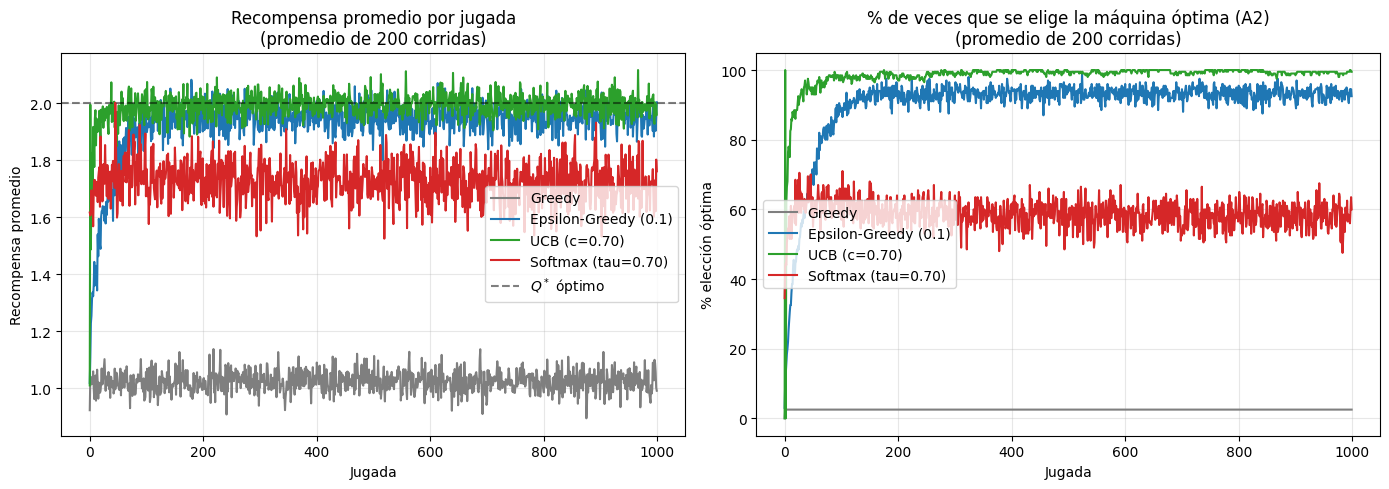

In [13]:
metodos_finales = {
    "Greedy": (recompensa_greedy, optima_greedy),
    "Epsilon-Greedy (0.1)": (resultados_eps[0.1]["recompensa"], resultados_eps[0.1]["optima"]),
    "UCB (c=0.70)": (resultados_ucb[0.70]["recompensa"], resultados_ucb[0.70]["optima"]),
    "Softmax (tau=0.70)": (resultados_softmax[0.70]["recompensa"], resultados_softmax[0.70]["optima"]),
}

colores_metodos = {
    "Greedy": "#7f7f7f",
    "Epsilon-Greedy (0.1)": "#1f77b4",
    "UCB (c=0.70)": "#2ca02c",
    "Softmax (tau=0.70)": "#d62728",
}

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

for nombre, (r, o) in metodos_finales.items():
    ax1.plot(r, color=colores_metodos[nombre], label=nombre, linewidth=1.5)
    ax2.plot(o, color=colores_metodos[nombre], label=nombre, linewidth=1.5)

ax1.axhline(Q_STAR[OPTIMO], color="black", linestyle="--", alpha=0.5, label="$Q^*$ óptimo")
ax1.set_title(f"Recompensa promedio por jugada\n(promedio de {N_CORRIDAS} corridas)")
ax1.set_xlabel("Jugada")
ax1.set_ylabel("Recompensa promedio")
ax1.legend()
ax1.grid(alpha=0.3)

ax2.set_title(f"% de veces que se elige la máquina óptima ({ARMS[OPTIMO]})\n(promedio de {N_CORRIDAS} corridas)")
ax2.set_xlabel("Jugada")
ax2.set_ylabel("% elección óptima")
ax2.legend()
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

### Comparación por familia de método: efecto del parámetro

Antes de fijarnos solo en la "mejor" configuración de cada método, veamos cómo cambia el desempeño **dentro** de cada familia al variar su parámetro ($\varepsilon$, $c$ o $\tau$).

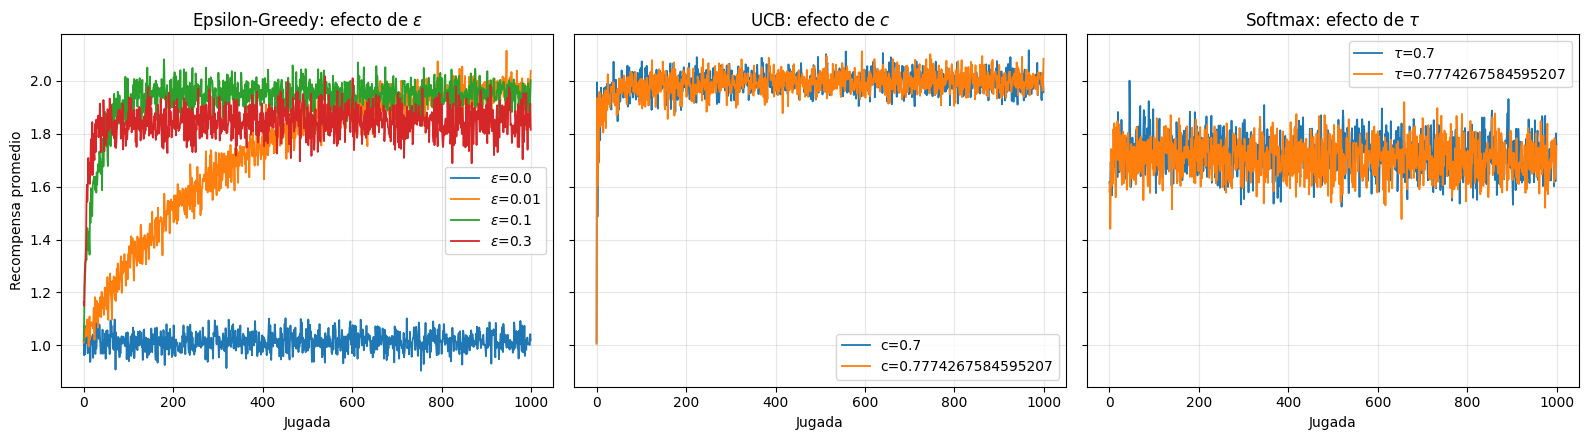

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5), sharey=True)

for eps, datos in resultados_eps.items():
    axes[0].plot(datos["recompensa"], label=f"$\\varepsilon$={eps}", linewidth=1.3)
axes[0].set_title("Epsilon-Greedy: efecto de $\\varepsilon$")
axes[0].set_xlabel("Jugada")
axes[0].set_ylabel("Recompensa promedio")
axes[0].legend()
axes[0].grid(alpha=0.3)

for c, datos in resultados_ucb.items():
    axes[1].plot(datos["recompensa"], label=f"c={c}", linewidth=1.3)
axes[1].set_title("UCB: efecto de $c$")
axes[1].set_xlabel("Jugada")
axes[1].legend()
axes[1].grid(alpha=0.3)

for tau, datos in resultados_softmax.items():
    axes[2].plot(datos["recompensa"], label=f"$\\tau$={tau}", linewidth=1.3)
axes[2].set_title("Softmax: efecto de $\\tau$")
axes[2].set_xlabel("Jugada")
axes[2].legend()
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 9. Comparación de estimaciones finales $Q(a)$ vs. valores reales $Q^*(a)$

Las secciones anteriores comparan la recompensa promedio y el % de elección óptima jugada a jugada, pero no muestran **qué tan bien terminó estimando cada método el valor real de cada máquina** una vez agotadas las 1000 jugadas. Aquí comparamos, para cada método, la estimación final $Q_T(a)$ (promediada sobre las `N_CORRIDAS` corridas) contra el valor real $Q^*(a)$, y calculamos el error de estimación $Q_T(a) - Q^*(a)$ por máquina.

Esto revela, por ejemplo, si un método terminó con una estimación muy desviada de $A_3$ (la máquina de alta varianza) por no haberla explorado lo suficiente, incluso si su recompensa promedio final fue razonable.

In [15]:
# Reutilizamos las mismas políticas/configuraciones de la sección 8
politicas_finales = {
    "Greedy": politica_greedy,
    "Epsilon-Greedy (0.1)": politica_epsilon_greedy(0.1),
    "UCB (c=0.70)": politica_ucb(0.70),
    "Softmax (tau=0.70)": politica_softmax(0.70),
}

Q_finales = {}
for nombre, politica in politicas_finales.items():
    Q_prom, Q_std = Q_final_promedio(politica)
    Q_finales[nombre] = {"Q_estimado": Q_prom, "Q_std": Q_std}

encabezado = f"{'Método':<25}" + "".join(f"{a + ' (est. vs real=' + str(Q_STAR[i]) + ')':>26}" for i, a in enumerate(ARMS))
print(encabezado)
print("-" * len(encabezado))
for nombre, datos in Q_finales.items():
    fila = f"{nombre:<25}"
    for i in range(K):
        error = datos["Q_estimado"][i] - Q_STAR[i]
        fila += f"{datos['Q_estimado'][i]:>18.3f} ({error:+.3f})"
    print(fila)

print(f"\n{'Método':<25}{'Error absoluto promedio |Q_est - Q*|':>38}")
print("-" * 63)
for nombre, datos in Q_finales.items():
    error_abs_prom = np.abs(datos["Q_estimado"] - Q_STAR).mean()
    print(f"{nombre:<25}{error_abs_prom:>38.4f}")

Método                        A1 (est. vs real=1.0)     A2 (est. vs real=2.0)     A3 (est. vs real=1.5)
-------------------------------------------------------------------------------------------------------
Greedy                                0.964 (-0.036)             0.060 (-1.940)             0.000 (-1.500)
Epsilon-Greedy (0.1)                  1.005 (+0.005)             1.998 (-0.002)             1.495 (-0.005)
UCB (c=0.70)                          0.868 (-0.132)             1.999 (-0.001)             0.767 (-0.733)
Softmax (tau=0.70)                    0.997 (-0.003)             1.998 (-0.002)             1.490 (-0.010)

Método                     Error absoluto promedio |Q_est - Q*|
---------------------------------------------------------------
Greedy                                                   1.1586
Epsilon-Greedy (0.1)                                     0.0038
UCB (c=0.70)                                             0.2888
Softmax (tau=0.70)                         

C:\Users\lawle\AppData\Local\Temp\ipykernel_20412\1648038253.py:32: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axErr.set_xticklabels(nombres_metodos, rotation=15)


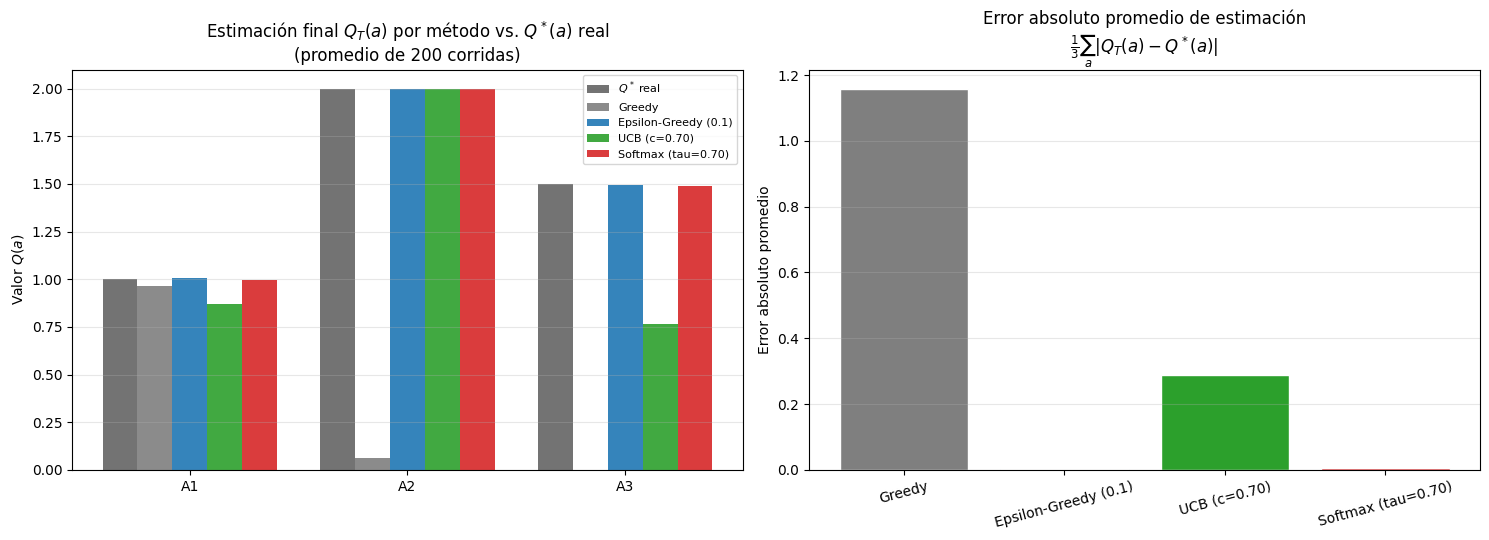

In [16]:
fig, (axQ, axErr) = plt.subplots(1, 2, figsize=(15, 5.5))

# --- Panel izquierdo: Q estimado por máquina y método, vs Q* real ---
etiquetas = ["$Q^*$ real"] + list(Q_finales.keys())
valores = [Q_STAR] + [Q_finales[n]["Q_estimado"] for n in Q_finales]
colores_barras = ["black"] + [colores_metodos[n] for n in Q_finales]

n_series = len(etiquetas)
ancho = 0.8 / n_series
x = np.arange(K)

for j, (etq, val, col) in enumerate(zip(etiquetas, valores, colores_barras)):
    offset = (j - (n_series - 1) / 2) * ancho
    alpha = 0.55 if etq == "$Q^*$ real" else 0.9
    axQ.bar(x + offset, val, ancho, label=etq, color=col, alpha=alpha)

axQ.set_xticks(x)
axQ.set_xticklabels(ARMS)
axQ.set_ylabel("Valor $Q(a)$")
axQ.set_title(f"Estimación final $Q_T(a)$ por método vs. $Q^*(a)$ real\n(promedio de {N_CORRIDAS} corridas)")
axQ.legend(fontsize=8)
axQ.grid(alpha=0.3, axis="y")

# --- Panel derecho: error absoluto promedio por método ---
nombres_metodos = list(Q_finales.keys())
errores_abs = [np.abs(Q_finales[n]["Q_estimado"] - Q_STAR).mean() for n in nombres_metodos]
colores_barra2 = [colores_metodos[n] for n in nombres_metodos]

axErr.bar(nombres_metodos, errores_abs, color=colores_barra2, edgecolor="white")
axErr.set_title("Error absoluto promedio de estimación\n$\\frac{1}{3}\\sum_a |Q_T(a) - Q^*(a)|$")
axErr.set_ylabel("Error absoluto promedio")
axErr.set_xticklabels(nombres_metodos, rotation=15)
axErr.grid(alpha=0.3, axis="y")

plt.tight_layout()
plt.show()

**Cómo leer esta comparación:** un error grande en $A_1$ o $A_3$ no es necesariamente malo — significa que el método dejó de explorar esa máquina pronto porque ya tenía evidencia suficiente de que no era la óptima. Lo que sí es señal de un método débil es un error grande en **$A_2$** (la máquina óptima real), porque implica que el método terminó con una estimación pobre de la opción que más le convenía explotar. _(Completa aquí, con los números que arroje tu ejecución, cuál método tuvo el menor error en $A_2$ y cuál tuvo el mayor error absoluto promedio.)_

## 10. Resumen numérico: recompensa acumulada total por método

In [17]:
print(f"{'Método':<25}{'Recompensa acum. total':>24}{'% jugadas óptimas':>20}")
print("-" * 69)

resumen = {}
for nombre, (r, o) in metodos_finales.items():
    total = r.sum()
    pct_opt_global = o.mean()
    resumen[nombre] = {"total": total, "pct_optima": pct_opt_global}
    print(f"{nombre:<25}{total:>24.2f}{pct_opt_global:>19.2f}%")

Método                     Recompensa acum. total   % jugadas óptimas
---------------------------------------------------------------------
Greedy                                    1024.60               2.50%
Epsilon-Greedy (0.1)                      1926.29              90.21%
UCB (c=0.70)                              1989.52              98.39%
Softmax (tau=0.70)                        1725.76              58.71%


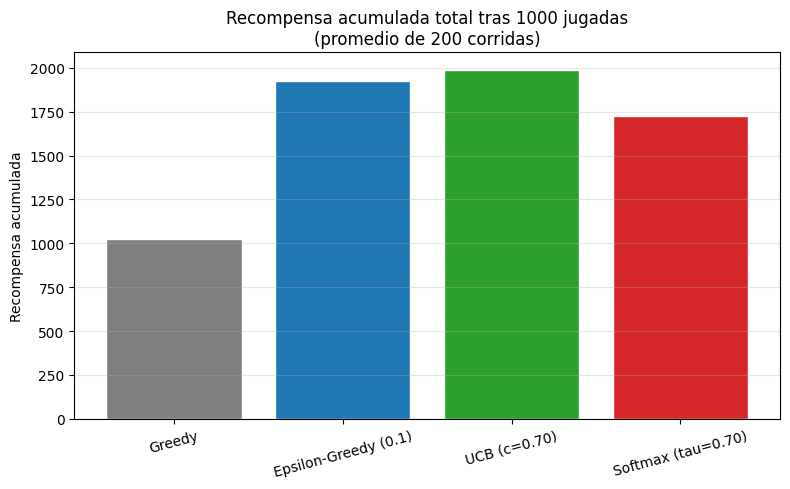

In [18]:
plt.figure(figsize=(8, 5))
nombres = list(resumen.keys())
totales = [resumen[n]["total"] for n in nombres]
colores_barra = [colores_metodos[n] for n in nombres]

plt.bar(nombres, totales, color=colores_barra, edgecolor="white")
plt.title(f"Recompensa acumulada total tras {N_JUGADAS} jugadas\n(promedio de {N_CORRIDAS} corridas)")
plt.ylabel("Recompensa acumulada")
plt.xticks(rotation=15)
plt.grid(alpha=0.3, axis="y")
plt.tight_layout()
plt.show()

## 11. ¿Qué papel juega la varianza de $A_3$ en cada método?

En el Reto 1 vimos que $A_3$ tiene la media más alta después de $A_2$, pero también la mayor varianza ($\sigma=1.5$). Esto la hace peligrosamente atractiva para métodos con poca exploración: una racha de recompensas altas por azar puede hacer que Greedy o un $\varepsilon$ muy bajo se "enganchen" con $A_3$ o con una estimación errónea, en vez de descubrir que $A_2$ es mejor en promedio. Los métodos con exploración dirigida (UCB) o exploración constante (Epsilon-Greedy, Softmax) tienen más oportunidades de corregir esa impresión inicial.

In [19]:
# Cuántas veces, en promedio, cada método terminó "convencido" de la máquina incorrecta
# (aproximación: última jugada de cada corrida, para el método Greedy vs Epsilon-Greedy(0.1))
def brazo_final_mas_jugado(politica, n_corridas=N_CORRIDAS, n_jugadas=N_JUGADAS):
    conteo_final = np.zeros(K, dtype=int)
    for _ in range(n_corridas):
        Q = np.zeros(K)
        N = np.zeros(K, dtype=int)
        for t in range(n_jugadas):
            a = politica(Q, N, t)
            R = reward(a)
            N[a] += 1
            Q[a] += (1.0 / N[a]) * (R - Q[a])
        conteo_final += (N == N.max())
    return conteo_final

for nombre, politica in [("Greedy", politica_greedy), ("Epsilon-Greedy (0.1)", politica_epsilon_greedy(0.1))]:
    conteo = brazo_final_mas_jugado(politica)
    print(f"{nombre}: brazo más jugado al final, por corrida -> " +
          ", ".join(f"{ARMS[i]}: {conteo[i]}/{N_CORRIDAS}" for i in range(K)))

Greedy: brazo más jugado al final, por corrida -> A1: 192/200, A2: 8/200, A3: 0/200


Epsilon-Greedy (0.1): brazo más jugado al final, por corrida -> A1: 0/200, A2: 200/200, A3: 0/200


## 12. Evidencia de uso de IA

_(Completa esta sección con honestidad según el trabajo de tu equipo.)_

**Prompts principales usados:**
1. _[Ejemplo: "Ayúdame a implementar epsilon-greedy, UCB y softmax reutilizando el simulador K-Armed Bandit del Reto 1"]_
2. _[Ejemplo: "¿Cómo comparo varias corridas del bandido para obtener curvas de recompensa promedio más estables?"]_
3. _[...]_

**Ajustes realizados manualmente:**
- _[Ejemplo: cambiamos los valores de epsilon, c y tau evaluados]_
- _[Ejemplo: agregamos el análisis de qué brazo queda "ganador" al final por corrida]_
- _[...]_

## 13. Conclusiones

_(Ajusta estas conclusiones con los valores exactos que arroje TU ejecución.)_

1. **Greedy** converge rápido pero es frágil: al no explorar, puede quedarse fijo en un brazo subóptimo si las primeras recompensas lo favorecen por azar, especialmente por la alta varianza de $A_3$.

2. **Epsilon-Greedy** mejora sobre Greedy al garantizar exploración constante; valores muy bajos de $\varepsilon$ (ej. 0.01) tardan más en corregir errores iniciales, mientras que valores muy altos (ej. 0.3) exploran de más y sacrifican recompensa a largo plazo.

3. **UCB** suele lograr el mejor equilibrio: explora de forma dirigida (prueba primero lo desconocido, luego prioriza incertidumbre) y termina identificando a $A_2$ como brazo óptimo de forma más consistente y con mayor recompensa acumulada, incluso con valores de $c$ relativamente bajos.

4. **Softmax** es sensible a $\tau$: con temperatura muy baja (ej. 0.1) puede converger prematuramente a un brazo subóptimo —igual que Greedy— si las primeras muestras lo favorecen por azar; con temperatura intermedia (ej. 0.5) equilibra mejor exploración y explotación; con temperatura alta (ej. 1.0) se acerca a una política aleatoria, sacrificando explotación.

5. **Conexión con el Reto 1:** la alta varianza de $A_3$ ($\sigma=1.5$) es precisamente lo que hace valiosa la exploración: los métodos que exploran más consistentemente logran mayor % de elección del brazo óptimo real ($A_2$) y mayor recompensa acumulada total.

6. **Estimación final vs. condiciones reales (sección 9):** comparar $Q_T(a)$ contra $Q^*(a)$ al final de las 1000 jugadas confirma lo anterior desde otro ángulo — no basta con mirar la recompensa acumulada, también importa qué tan cerca terminó cada método de conocer el valor real de la máquina óptima $A_2$. _(Completa: ¿qué método tuvo el menor error absoluto promedio? ¿coincide con el que tuvo mejor recompensa acumulada y mayor % de elección óptima?)_